In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [4]:
parent_llm = ChatMistralAI(model='mistral-large-latest')
subgraph_llm = ChatMistralAI(model='mistral-small-latest')

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [8]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

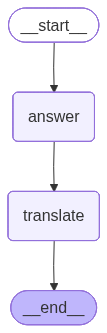

In [9]:
graph = parent_builder.compile()

graph

In [10]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum Physics** (or **Quantum Mechanics**) is a fundamental branch of physics that describes the behavior of matter and energy at the smallest scales—typically atoms and subatomic particles (like electrons, protons, and photons). It provides a mathematical framework to explain phenomena that classical physics (Newtonian mechanics, electromagnetism) cannot, such as:\n\n### **Key Principles of Quantum Physics:**\n1. **Wave-Particle Duality**\n   - Particles (e.g., electrons, photons) exhibit both **particle-like** (localized) and **wave-like** (spread-out) properties.\n   - Example: Light acts as a wave (interference patterns) but also as particles (photons in the photoelectric effect).\n\n2. **Quantization**\n   - Certain properties (e.g., energy, angular momentum) are **quantized**, meaning they can only take discrete values, not continuous ones.\n   - Example: Electrons in an atom occupy specific energy levels (quantum states